# Enrichment / enhancement metrics — virus intensity on CD31 vessels

The specificity question is "**is the virus concentrated on the vasculature?**"
The soundest way to ask it is *not* to segment the virus at all. Define vessels
from CD31 (the ground-truth endothelial stain) and measure whether the virus is
**brighter on vessels than off them**. This avoids the near-tautology of
segmenting the virus into tubes and then asking whether it looks tubular (the
issue flagged at the end of `dice_between_channels.ipynb`).

All code reuses the merged `scripts/`, so the numbers match the command-line
tools.

## Method A — threshold-free CD31 percentile  *(primary)*

Call the top **q%** of CD31 intensity within tissue "vessel", and compute

$$\text{enrichment}(q) = \frac{\text{mean virus where CD31 is in its top } q\%}{\text{mean virus in the rest of the tissue}}$$

Sweep $q \in \{2,5,10,20,30\}$. There is no filter and no threshold on a response —
the only knob is $q$, and it is swept, so a regional ordering that holds **across
$q$** is a property of the data, not of where a line was drawn. Enrichment is a
ratio of virus intensities, so a per-section brightness gain cancels: it is truly
threshold-free on the virus side.

## Method B — CD31 vessel mask  *(secondary, robustness check)*

Segment CD31 with the Jerman pipeline and measure the virus inside vs outside:

- **enrichment** = mean virus in vessels / mean virus in parenchyma,
- **coverage** = fraction of vessel area that is virus-positive (how much of the
  vasculature the virus reaches),
- **off_target** = fraction of virus-positive area lying *off* vessels
  (parenchymal leak).

"virus-positive" is set per image from its own parenchyma (median + 3·MAD),
because acquisition brightness was tuned per image.

> ⚠️ **Caveat.** On this dataset the mask pipeline's calibrated `reference_lambda`
> (~0.5) saturates the Jerman response, so the CD31 "vessel" mask covers **~45% of
> the tissue** — essentially grey matter, not vessels. Treat Method B as a
> cross-check on the regional **ordering**, not as the source of the enrichment
> magnitude. Method A is the measure to quote.

In [1]:
# Bootstrap: walk up to the repo root (the folder with pyproject.toml) and put it
# and scripts/ on sys.path, so this notebook runs from a plain clone with no
# install step -- the same pattern the archive notebooks use.
import sys
from pathlib import Path

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
for _p in (str(_root), str(_root / "scripts")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt
pd.set_option("display.width", 120)

from enrichment_by_cd31_percentile import PERCENTILES, enrichment_curve
from analyse_spinal_cord import (NAME, REGION_NAME, analyse, calibrate_reference,
                                 curated_paths, tissue_mask)
from visualize_sections import VIS_Q, top_q_mask, _result_rgb

# visualize_sections sets matplotlib to the non-interactive Agg backend on import,
# which silences plt.show(); re-assert the inline backend here, after the imports,
# so figures render in the notebook.
%matplotlib inline

RUN_FULL = False   # flip to run every section

In [2]:
paths = curated_paths() if RUN_FULL else curated_paths(pilot_mice=2, slices_per_region=1)
print(f"{len(paths)} sections ({'full dataset' if RUN_FULL else 'pilot'})")

10 sections (pilot)


### Method A — percentile enrichment (fast; no segmentation)

In [3]:
rows = []
for path in paths:
    figure, mouse, region, reporter, slice_id = NAME.match(path.name).groups()
    reporter = "SYFP2" if "SYFP2" in reporter else ("tdT" if "tdT" in reporter else reporter)
    stack = tifffile.imread(path)
    if stack.ndim != 3 or stack.shape[0] != 2:
        continue
    virus, cd31 = stack[0].astype(np.float32), stack[1].astype(np.float32)
    try:
        tissue = tissue_mask(virus, cd31)
    except ValueError as error:
        print(f"skip {path.name}: {error}")
        continue
    curve = enrichment_curve(virus, cd31, tissue)
    rows.append(dict(figure=figure, reporter=reporter, mouse=mouse, region=region,
                     slice=slice_id or "", **{f"q{q}": curve[q] for q in PERCENTILES}))

pct = pd.DataFrame(rows)
pct.round(3)

,figure,reporter,mouse,region,slice,q2,q5,q10,q20,q30
0,Fig 1,SYFP2,M131,C,1,1.642,1.572,1.537,1.536,1.646
1,Fig 1,SYFP2,M131,L,11,1.343,1.259,1.218,1.197,1.224
2,Fig 1,SYFP2,M131,T,10,1.615,1.535,1.496,1.501,1.587
3,Fig 1,SYFP2,M132,C,1,1.725,1.614,1.569,1.502,1.510
4,Fig 1,SYFP2,M132,L,11,1.343,1.293,1.263,1.246,1.277
5,Fig 1,SYFP2,M132,T,6,1.647,1.619,1.580,1.626,1.828
6,Fig 2a,tdT,M63,C,10,4.391,3.293,2.564,2.067,1.920
7,Fig 2a,tdT,M63,L,3,3.336,3.106,2.873,2.391,2.175
8,Fig 2a,tdT,M63,T,1,3.560,3.389,2.916,2.443,2.292
9,Fig 2b,tdT,M87,TL,5,1.555,1.511,1.475,1.386,1.303


Aggregate: slices → mouse × region, then mean across mice, per reporter. A value
above 1 means the virus is brighter on CD31-bright vessels than elsewhere.

In [4]:
qcols = [f"q{q}" for q in PERCENTILES]
per_mouse = pct.groupby(["reporter", "mouse", "region"])[qcols].mean().reset_index()
region_mean = per_mouse.groupby(["reporter", "region"])[qcols].mean().round(3)
region_mean

q2     q5    q10    q20    q30
reporter region                                   
SYFP2    C       1.684  1.593  1.553  1.519  1.578
         L       1.343  1.276  1.240  1.222  1.251
         T       1.631  1.577  1.538  1.564  1.707
tdT      C       4.391  3.293  2.564  2.067  1.920
         L       3.336  3.106  2.873  2.391  2.175
         T       3.560  3.389  2.916  2.443  2.292
         TL      1.555  1.511  1.475  1.386  1.303

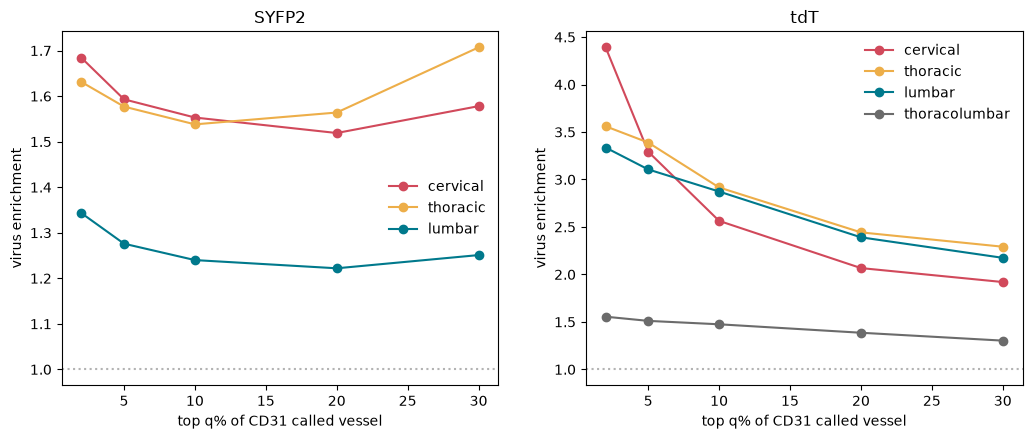

In [5]:
# Enrichment vs q, one line per region -- a line that stays lowest across the whole
# sweep is the robust part of the result.
colour = {"C": "#d1495b", "T": "#edae49", "L": "#00798c", "TL": "#6b6b6b"}
long = {"C": "cervical", "T": "thoracic", "L": "lumbar", "TL": "thoracolumbar"}
reporters = list(region_mean.index.get_level_values(0).unique())
fig, axes = plt.subplots(1, len(reporters), figsize=(6.2 * len(reporters), 4.6), squeeze=False)
for ax, reporter in zip(axes[0], reporters):
    for region in ["C", "T", "L", "TL"]:
        if (reporter, region) not in region_mean.index:
            continue
        ax.plot(PERCENTILES, region_mean.loc[(reporter, region), qcols].values,
                "-o", color=colour[region], label=long[region])
    ax.axhline(1.0, color="0.7", ls=":")
    ax.set_xlabel("top q% of CD31 called vessel"); ax.set_ylabel("virus enrichment")
    ax.set_title(reporter); ax.legend(frameon=False)
plt.show()

### Method B — CD31 vessel mask (enrichment, coverage, off-target)

In [6]:
reference = calibrate_reference(paths, n_sections=min(6, len(paths)))

rows = []
for path in paths:
    figure, mouse, region, reporter, slice_id = NAME.match(path.name).groups()
    reporter = "SYFP2" if "SYFP2" in reporter else ("tdT" if "tdT" in reporter else reporter)
    try:
        m = analyse(path, reference)
    except Exception as error:
        print(f"skip {path.name}: {error}")
        continue
    rows.append(dict(reporter=reporter, mouse=mouse, region=region,
                     enrichment=m["enrichment"], coverage=m["coverage"],
                     off_target=m["off_target"], vessel_area_fraction=m["vessel_area_fraction"]))

mask = pd.DataFrame(rows)
mask.round(3)

   Fig 1_M131_C_SYFP2-green_CD31-mag_slice1.tif   lambda_max       0.6


   Fig 1_M131_L_SYFP2-green_CD31-mag_slice11.tif  lambda_max       0.5


   Fig 1_M131_T_SYFP2-green_CD31-mag_slice10.tif  lambda_max       0.5


   Fig 1_M132_C_SYFP2-green_CD31-mag_slice1.tif   lambda_max       0.6


   Fig 1_M132_L_SYFP2-green_CD31-mag_slice11.tif  lambda_max       0.5


   Fig 1_M132_T_SYFP2-green_CD31-mag_slice6.tif   lambda_max       0.7
   -> dataset reference_lambda = 0.6 (median of 6; spread 1-1)


,reporter,mouse,region,enrichment,coverage,off_target,vessel_area_fraction
0,SYFP2,M131,C,1.425,0.034,0.100,0.426
1,SYFP2,M131,L,1.166,0.009,0.026,0.501
2,SYFP2,M131,T,1.415,0.221,0.345,0.410
3,SYFP2,M132,C,1.324,0.017,0.003,0.444
4,SYFP2,M132,L,1.192,0.007,0.032,0.489
5,SYFP2,M132,T,1.478,0.440,0.385,0.422
6,tdT,M63,C,2.017,0.223,0.218,0.479
7,tdT,M63,L,2.153,0.230,0.132,0.424
8,tdT,M63,T,2.289,0.262,0.217,0.407
9,tdT,M87,TL,1.188,0.139,0.126,0.540


Note the **`vessel_area_fraction` ≈ 0.4–0.5** column: the CD31 mask is capturing
nearly half the tissue, the over-segmentation warned about above. The enrichment
*ordering* by region can still be compared to Method A, but the magnitude is not
a vessel-vs-parenchyma contrast at this operating point.

In [7]:
mask.groupby(["reporter", "region"])[["enrichment", "coverage", "off_target",
                                       "vessel_area_fraction"]].mean().round(3)

enrichment  coverage  off_target  vessel_area_fraction
reporter region                                                        
SYFP2    C            1.375     0.026       0.052                 0.435
         L            1.179     0.008       0.029                 0.495
         T            1.446     0.331       0.365                 0.416
tdT      C            2.017     0.223       0.218                 0.479
         L            2.153     0.230       0.132                 0.424
         T            2.289     0.262       0.217                 0.407
         TL           1.188     0.139       0.126                 0.540

## Visual check — Method A on one section

Dim grey virus everywhere; pixels on the top-*q%* CD31 vessels tinted green in
proportion to the virus intensity there. A vessel bed the virus reaches glows;
one it misses stays dark. The enrichment number is that contrast, quantified.

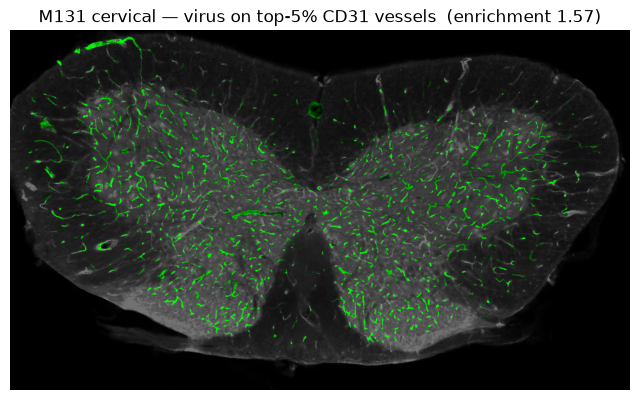

In [8]:
path = paths[0]
stack = tifffile.imread(path)
virus, cd31 = stack[0].astype(np.float32), stack[1].astype(np.float32)
tissue = tissue_mask(virus, cd31)
vessels = top_q_mask(cd31, tissue, VIS_Q)
curve = enrichment_curve(virus, cd31, tissue)

d = np.s_[::2, ::2]
figure, mouse, region, reporter, slice_id = NAME.match(path.name).groups()
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(_result_rgb(virus[d], tissue[d], vessels[d]))
ax.set_title(f"{mouse} {REGION_NAME[region]} — virus on top-{VIS_Q}% CD31 vessels"
             f"  (enrichment {curve[VIS_Q]:.2f})")
ax.axis("off")
plt.show()

## Interpretation

- **Enrichment** (Method A) is the primary, defensible number: threshold-free,
  never segments the virus, and stable across the *q* sweep. Report it.
- **Coverage** and **off_target** (Method B) add the directional detail — how much
  vasculature is reached, and how much signal leaks into parenchyma — but inherit
  the mask's over-segmentation, so lean on their *ordering*, not their magnitude.
- Across both methods and the whole *q* sweep, **SYFP2 lumbar enrichment is the
  lowest** and that holds in every mouse; cervical-vs-thoracic is genuinely
  ambiguous. M63 (tdT) is markedly more vessel-restricted (higher enrichment).